# Resultados

Comparaciones necesarias

- Por modelo.
- Por tienda.
- Por familia.
- Por periodo temporal.
- En días festivos.
- Con y sin promoción.
- Para productos con ventas altas y bajas.

In [1]:
# =============================================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_log_error,
    root_mean_squared_error,
)

In [ ]:
# =============================================================================
# RUTAS
# =============================================================================

PROJECT_ROOT = Path("..")

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

RESULTS_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
)


PREPARED_DATA_PATH = (
    PROCESSED_DATA_PATH
    / "train_prepared.parquet"
)

SPLIT_PATH = (
    PROCESSED_DATA_PATH
    / "temporal_split_dates.csv"
)

ML_RESULTS_PATH = (
    RESULTS_DATA_PATH
    / "machine_learning_validation_results.csv"
)

BASELINE_RESULTS_PATH = (
    RESULTS_DATA_PATH
    / "baseline_validation_results.csv"
)

DEVELOPMENT_TRAIN_DAYS = 90

# =============================================================================
# RUTA PARA GUARDAR LAS FIGURAS DE EVALUACIÓN E INTERPRETABILIDAD
# =============================================================================

INTERPRETABILITY_FIGURES_PATH = (
    PROJECT_ROOT
    / "figures"
    / "06_resultados_interpretabilidad"
)

INTERPRETABILITY_FIGURES_PATH.mkdir(
    parents=True,
    exist_ok=True,
)



In [3]:
# =============================================================================
# 2. FUNCIONES DE EVALUACIÓN
# =============================================================================

def rmsle(y_true, y_pred):
    """
    Root Mean Squared Logarithmic Error.

    Las predicciones negativas se limitan a cero,
    ya que las ventas no pueden ser negativas.
    """

    y_true = np.asarray(y_true)
    y_pred = np.clip(
        np.asarray(y_pred),
        0,
        None,
    )

    return np.sqrt(
        mean_squared_log_error(
            y_true,
            y_pred,
        )
    )


def wape(y_true, y_pred):
    """
    Weighted Absolute Percentage Error.

    WAPE =
    sum(|real - predicción|)
    -------------------------
         sum(|real|)
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = np.abs(y_true).sum()

    if denominator == 0:
        return np.nan

    return (
        np.abs(
            y_true - y_pred
        ).sum()
        / denominator
    ) * 100


def calculate_metrics(
    y_true,
    y_pred,
):
    """
    Calcula todas las métricas utilizadas
    en la evaluación.
    """

    y_true = np.asarray(y_true)

    y_pred = np.clip(
        np.asarray(y_pred),
        0,
        None,
    )

    return pd.Series(
        {
            "RMSLE": rmsle(
                y_true,
                y_pred,
            ),

            "MAE": mean_absolute_error(
                y_true,
                y_pred,
            ),

            "RMSE": root_mean_squared_error(
                y_true,
                y_pred,
            ),

            "WAPE": wape(
                y_true,
                y_pred,
            ),

            "observations": len(
                y_true
            ),
        }
    )

In [4]:
# =============================================================================
# 3. COMPARACIÓN GLOBAL DE MODELOS
# =============================================================================

ml_results = pd.read_csv(
    ML_RESULTS_PATH
)


# Nos quedamos únicamente con los modelos
# entrenados con la misma ventana temporal.

ml_results = ml_results.loc[
    ml_results["development_train_days"]
    == DEVELOPMENT_TRAIN_DAYS
].copy()


# Ordenamos por RMSLE, que es la métrica
# principal de la competición.

ml_results = (
    ml_results
    .sort_values("RMSLE")
    .reset_index(drop=True)
)


display(
    ml_results[
        [
            "model",
            "RMSLE",
            "MAE",
            "RMSE",
            "training_seconds",
        ]
    ]
)


winner = ml_results.iloc[0]


print("=" * 80)
print("MODELO GANADOR")
print("=" * 80)

print(
    f"Modelo: {winner['model']}"
)

print(
    f"RMSLE: {winner['RMSLE']:.5f}"
)

print(
    f"MAE: {winner['MAE']:.2f}"
)

print(
    f"RMSE: {winner['RMSE']:.2f}"
)

,model,RMSLE,MAE,RMSE,training_seconds
0,lightgbm,0.375019,55.897614,228.999420,6.185183
1,xgboost,0.375438,56.188023,231.231674,4.889679
2,hist_gradient_boosting,0.376639,57.323353,239.629562,6.111417
3,catboost,0.378827,58.943275,232.837219,69.853584
4,random_forest,0.389130,69.178596,326.734558,3.458364
5,decision_tree,0.397880,63.146496,252.713272,3.527765
6,ridge,0.642323,192.105118,1181.149170,1.691368


MODELO GANADOR
Modelo: lightgbm
RMSLE: 0.37502
MAE: 55.90
RMSE: 229.00


In [5]:
# =============================================================================
# COMPARACIÓN CON EL MEJOR BASELINE
# =============================================================================

baseline_results = pd.read_csv(
    BASELINE_RESULTS_PATH
)

best_baseline = (
    baseline_results
    .sort_values("RMSLE")
    .iloc[0]
)

best_ml = winner


improvement = (
    (
        best_baseline["RMSLE"]
        - best_ml["RMSLE"]
    )
    / best_baseline["RMSLE"]
) * 100


print("=" * 80)
print("COMPARACIÓN FINAL")
print("=" * 80)

print(
    f"Mejor baseline: "
    f"{best_baseline['model']} "
    f"(RMSLE = {best_baseline['RMSLE']:.5f})"
)

print(
    f"Mejor modelo ML: "
    f"{best_ml['model']} "
    f"(RMSLE = {best_ml['RMSLE']:.5f})"
)

if improvement > 0:
    print(
        f"\nEl modelo {best_ml['model']} mejora "
        f"al mejor baseline en un {improvement:.2f}%."
    )
else:
    print(
        f"\nEl modelo ML no mejora al baseline."
    )

COMPARACIÓN FINAL
Mejor baseline: Media móvil 14 días (RMSLE = 0.45599)
Mejor modelo ML: lightgbm (RMSLE = 0.37502)

El modelo lightgbm mejora al mejor baseline en un 17.76%.


In [6]:
# =============================================================================
# 4. WAPE POR MODELO
# =============================================================================

model_metrics = []


for model_name in ml_results["model"]:

    prediction_path = (
        RESULTS_DATA_PATH
        / (
            f"predictions_"
            f"{model_name}_"
            f"{DEVELOPMENT_TRAIN_DAYS}d.parquet"
        )
    )

    if not prediction_path.exists():

        print(
            f"No se encontró: "
            f"{prediction_path.name}"
        )

        continue


    predictions_df = pd.read_parquet(
        prediction_path
    )


    metrics = calculate_metrics(
        predictions_df["sales"],
        predictions_df["prediction"],
    )


    metrics["model"] = model_name

    model_metrics.append(
        metrics
    )


model_metrics_df = pd.DataFrame(
    model_metrics
)


model_metrics_df = (
    model_metrics_df
    .sort_values("RMSLE")
    .reset_index(drop=True)
)


display(
    model_metrics_df[
        [
            "model",
            "RMSLE",
            "MAE",
            "RMSE",
            "WAPE",
            "observations",
        ]
    ]
)

,model,RMSLE,MAE,RMSE,WAPE,observations
0,lightgbm,0.375019,55.897614,228.999420,11.717067,49896.0
1,xgboost,0.375438,56.188023,231.231674,11.777941,49896.0
2,hist_gradient_boosting,0.376639,57.323353,239.629562,12.015925,49896.0
3,catboost,0.378827,58.943275,232.837219,12.355489,49896.0
4,random_forest,0.389130,69.178596,326.734558,14.500982,49896.0
5,decision_tree,0.397880,63.146496,252.713272,13.236552,49896.0
6,ridge,0.642323,192.105118,1181.149170,40.268418,49896.0


In [7]:
# =============================================================================
# 5. PREDICCIONES FINALES DEL MODELO GANADOR
# =============================================================================

BEST_MODEL = "lightgbm"

best_predictions_path = (
    RESULTS_DATA_PATH
    / "predictions_lightgbm_final_test.parquet"
)

if not best_predictions_path.exists():
    raise FileNotFoundError(
        f"No se encuentran las predicciones finales: "
        f"{best_predictions_path}"
    )

evaluation_df = pd.read_parquet(
    best_predictions_path
)

evaluation_df["date"] = pd.to_datetime(
    evaluation_df["date"]
)

print("=" * 80)
print("PREDICCIONES FINALES DEL MODELO GANADOR")
print("=" * 80)

print(
    f"Modelo analizado: {BEST_MODEL}"
)

print(
    "Periodo: TEST INTERNO RESERVADO"
)

print(
    f"Dimensiones: {evaluation_df.shape}"
)

display(
    evaluation_df.head()
)

PREDICCIONES FINALES DEL MODELO GANADOR
Modelo analizado: lightgbm
Periodo: TEST INTERNO RESERVADO
Dimensiones: (49896, 5)


,date,store_nbr,family,sales,prediction
0,2017-07-19,1,AUTOMOTIVE,7.0,3.518848
1,2017-07-19,1,BABY CARE,0.0,0.070182
2,2017-07-19,1,BEAUTY,3.0,3.471102
3,2017-07-19,1,BEVERAGES,2369.0,2440.361084
4,2017-07-19,1,BOOKS,0.0,0.271482


In [ ]:
# =============================================================================
# 6. INFORMACIÓN ADICIONAL DEL TEST INTERNO
# =============================================================================

split_dates = pd.read_csv(
    SPLIT_PATH,
    parse_dates=[
        "start_date",
        "end_date",
    ],
)


# Recuperamos las fechas del test interno.
test_row = split_dates.loc[
    split_dates["partition"] == "test"
].iloc[0]

test_start = test_row["start_date"]
test_end = test_row["end_date"]


print(
    f"Periodo de test: "
    f"{test_start.date()} - {test_end.date()}"
)


# Variables necesarias para analizar promociones y festivos.
additional_columns = [
    "date",
    "store_nbr",
    "family",
    "onpromotion",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
]


test_features = pd.read_parquet(
    PREPARED_DATA_PATH,
    columns=additional_columns,
    filters=[
        (
            "date",
            ">=",
            test_start,
        ),
        (
            "date",
            "<=",
            test_end,
        ),
    ],
)


test_features["date"] = pd.to_datetime(
    test_features["date"]
)


print(
    "Dimensiones de variables de test:",
    test_features.shape,
)


assert len(test_features) == len(evaluation_df), (
    "El número de filas del test no coincide con las predicciones."
)


evaluation_df = evaluation_df.merge(
    test_features,
    on=[
        "date",
        "store_nbr",
        "family",
    ],
    how="left",
    validate="one_to_one",
)

print(
    "Nulos en onpromotion:",
    evaluation_df["onpromotion"].isna().sum(),
)

print(
    "Nulos en festivos nacionales:",
    evaluation_df["is_national_holiday"].isna().sum(),
)


# Un día se considera festivo si existe cualquiera de
# los tres niveles: nacional, regional o local.
evaluation_df["is_holiday"] = (
    evaluation_df[
        [
            "is_national_holiday",
            "is_regional_holiday",
            "is_local_holiday",
        ]
    ]
    .max(axis=1)
    .fillna(0)
    .astype("int8")
)


evaluation_df["promotion_group"] = np.where(
    evaluation_df["onpromotion"] > 0,
    "Con promoción",
    "Sin promoción",
)


evaluation_df["holiday_group"] = np.where(
    evaluation_df["is_holiday"] == 1,
    "Festivo",
    "No festivo",
)


display(
    evaluation_df.head()
)

Periodo de test: 2017-07-19 - 2017-08-15
Dimensiones de variables de test: (49896, 7)
Nulos en onpromotion: 0
Nulos en festivos nacionales: 0


,date,store_nbr,family,sales,prediction,onpromotion,is_national_holiday,is_regional_holiday,is_local_holiday,is_holiday,promotion_group,holiday_group
0,2017-07-19,1,AUTOMOTIVE,7.0,3.518848,0,0,0,0,0,Sin promoción,No festivo
1,2017-07-19,1,BABY CARE,0.0,0.070182,0,0,0,0,0,Sin promoción,No festivo
2,2017-07-19,1,BEAUTY,3.0,3.471102,0,0,0,0,0,Sin promoción,No festivo
3,2017-07-19,1,BEVERAGES,2369.0,2440.361084,34,0,0,0,0,Con promoción,No festivo
4,2017-07-19,1,BOOKS,0.0,0.271482,0,0,0,0,0,Sin promoción,No festivo


In [9]:
# =============================================================================
# 7. RESULTADOS POR TIENDA
# =============================================================================

results_by_store = (
    evaluation_df
    .groupby(
        "store_nbr",
        observed=True,
    )
    .apply(
        lambda group:
        calculate_metrics(
            group["sales"],
            group["prediction"],
        ),
        include_groups=False,
    )
    .reset_index()
)


results_by_store = (
    results_by_store
    .sort_values("RMSLE")
    .reset_index(drop=True)
)


display(
    results_by_store
)

,store_nbr,RMSLE,MAE,RMSE,WAPE,observations
0,3,0.295139,90.073715,274.619873,8.529619,924.0
1,6,0.299833,46.538082,131.734161,9.172583,924.0
2,44,0.313036,153.487305,492.588928,11.770036,924.0
3,49,0.318739,85.127457,243.611267,8.637305,924.0
4,46,0.323359,105.739326,361.905640,11.761147,924.0
5,8,0.324480,54.452827,155.782394,8.584277,924.0
6,2,0.326773,45.508396,123.346527,10.701594,924.0
7,4,0.328333,39.672283,110.198845,10.709000,924.0
8,24,0.332740,57.678120,158.998291,11.067045,924.0
9,7,0.336719,52.406757,143.946396,9.521826,924.0


In [10]:
print("10 tiendas con menor RMSLE")

display(
    results_by_store.head(10)
)


print("10 tiendas con mayor RMSLE")

display(
    results_by_store.tail(10)
)

10 tiendas con menor RMSLE


,store_nbr,RMSLE,MAE,RMSE,WAPE,observations
0,3,0.295139,90.073715,274.619873,8.529619,924.0
1,6,0.299833,46.538082,131.734161,9.172583,924.0
2,44,0.313036,153.487305,492.588928,11.770036,924.0
3,49,0.318739,85.127457,243.611267,8.637305,924.0
4,46,0.323359,105.739326,361.905640,11.761147,924.0
5,8,0.324480,54.452827,155.782394,8.584277,924.0
6,2,0.326773,45.508396,123.346527,10.701594,924.0
7,4,0.328333,39.672283,110.198845,10.709000,924.0
8,24,0.332740,57.678120,158.998291,11.067045,924.0
9,7,0.336719,52.406757,143.946396,9.521826,924.0


10 tiendas con mayor RMSLE


,store_nbr,RMSLE,MAE,RMSE,WAPE,observations
44,10,0.425926,33.704758,130.323639,16.429891,924.0
45,34,0.425980,38.520641,115.508789,11.764061,924.0
46,28,0.428784,82.241402,281.922363,17.821521,924.0
47,36,0.435397,55.488800,184.989502,14.698496,924.0
48,30,0.435589,52.917744,230.677170,26.724729,924.0
49,25,0.436831,62.544968,234.847260,22.103751,924.0
50,14,0.446141,58.359577,244.969604,22.799909,924.0
51,26,0.456120,31.689667,92.868607,21.154428,924.0
52,22,0.458485,43.876163,127.618423,19.856441,924.0
53,19,0.479428,37.292850,113.737000,13.111396,924.0


In [11]:
# =============================================================================
# 8. RESULTADOS POR FAMILIA
# =============================================================================

results_by_family = (
    evaluation_df
    .groupby(
        "family",
        observed=True,
    )
    .apply(
        lambda group:
        calculate_metrics(
            group["sales"],
            group["prediction"],
        ),
        include_groups=False,
    )
    .reset_index()
)


results_by_family = (
    results_by_family
    .sort_values("RMSLE")
    .reset_index(drop=True)
)


display(
    results_by_family
)

,family,RMSLE,MAE,RMSE,WAPE,observations
0,BOOKS,0.088205,0.034544,0.126733,237.410355,1512.0
1,PRODUCE,0.142850,214.582840,365.699615,9.343483,1512.0
2,DAIRY,0.143925,82.663689,128.358292,9.829422,1512.0
3,GROCERY I,0.151383,498.327972,747.816589,10.910640,1512.0
4,BREAD/BAKERY,0.167034,60.473751,96.434258,11.325957,1512.0
5,DELI,0.179073,37.952770,54.258247,12.499253,1512.0
6,MEATS,0.204186,50.549770,82.808990,13.411996,1512.0
7,BEVERAGES,0.204829,504.418243,776.810120,14.250761,1512.0
8,POULTRY,0.207829,48.162704,89.029205,12.629721,1512.0
9,HOME CARE,0.214155,50.117073,78.830467,16.395316,1512.0


In [12]:
# =============================================================================
# 9. RESULTADOS POR PERIODO TEMPORAL
# =============================================================================

evaluation_df["week_start"] = (
    evaluation_df["date"]
    .dt
    .to_period("W")
    .apply(
        lambda period:
        period.start_time
    )
)


results_by_period = (
    evaluation_df
    .groupby(
        "week_start",
        observed=True,
    )
    .apply(
        lambda group:
        calculate_metrics(
            group["sales"],
            group["prediction"],
        ),
        include_groups=False,
    )
    .reset_index()
)


display(
    results_by_period
)

,week_start,RMSLE,MAE,RMSE,WAPE,observations
0,2017-07-17,0.378211,52.631882,182.580811,11.176452,8910.0
1,2017-07-24,0.391049,60.089516,228.797073,12.657556,12474.0
2,2017-07-31,0.382640,68.019989,232.924103,13.236438,12474.0
3,2017-08-07,0.393205,70.382317,253.966095,16.302389,12474.0
4,2017-08-14,0.379914,47.295856,159.874634,11.063545,3564.0


In [13]:
# =============================================================================
# 10. RESULTADOS EN FESTIVOS
# =============================================================================

results_by_holiday = (
    evaluation_df
    .groupby(
        "holiday_group",
        observed=True,
    )
    .apply(
        lambda group:
        calculate_metrics(
            group["sales"],
            group["prediction"],
        ),
        include_groups=False,
    )
    .reset_index()
)


display(
    results_by_holiday
)

,holiday_group,RMSLE,MAE,RMSE,WAPE,observations
0,Festivo,0.415720,72.745354,231.584946,16.579759,2409.0
1,No festivo,0.384899,61.874962,224.493881,13.128999,47487.0


In [14]:
# =============================================================================
# 11. RESULTADOS SEGÚN PROMOCIÓN
# =============================================================================

results_by_promotion = (
    evaluation_df
    .groupby(
        "promotion_group",
        observed=True,
    )
    .apply(
        lambda group:
        calculate_metrics(
            group["sales"],
            group["prediction"],
        ),
        include_groups=False,
    )
    .reset_index()
)


display(
    results_by_promotion
)

,promotion_group,RMSLE,MAE,RMSE,WAPE,observations
0,Con promoción,0.304559,134.453110,342.564606,13.160095,21260.0
1,Sin promoción,0.437432,8.905793,31.019278,14.860769,28636.0


In [15]:
# =============================================================================
# 12. PRODUCTOS CON VENTAS ALTAS Y BAJAS
# =============================================================================

train_row = split_dates.loc[
    split_dates["partition"]
    == "train"
].iloc[0]


train_start = train_row["start_date"]
train_end = train_row["end_date"]


historical_sales = pd.read_parquet(
    PREPARED_DATA_PATH,
    columns=[
        "date",
        "family",
        "sales",
    ],
    filters=[
        (
            "date",
            ">=",
            train_start,
        ),
        (
            "date",
            "<=",
            train_end,
        ),
    ],
)


family_sales_level = (
    historical_sales
    .groupby(
        "family",
        observed=True,
    )["sales"]
    .mean()
    .reset_index(
        name="historical_mean_sales"
    )
)


# Clasificación en tres grupos mediante cuantiles.

family_sales_level[
    "sales_level"
] = pd.qcut(
    family_sales_level[
        "historical_mean_sales"
    ],
    q=3,
    labels=[
        "Ventas bajas",
        "Ventas medias",
        "Ventas altas",
    ],
)


evaluation_df = evaluation_df.merge(
    family_sales_level,
    on="family",
    how="left",
    validate="many_to_one",
)


results_by_sales_level = (
    evaluation_df
    .groupby(
        "sales_level",
        observed=True,
    )
    .apply(
        lambda group:
        calculate_metrics(
            group["sales"],
            group["prediction"],
        ),
        include_groups=False,
    )
    .reset_index()
)


display(
    results_by_sales_level
)

,sales_level,RMSLE,MAE,RMSE,WAPE,observations
0,Ventas bajas,0.439163,3.429023,22.431549,39.332622,16632.0
1,Ventas medias,0.463306,13.498909,31.445515,22.476013,16632.0
2,Ventas altas,0.201246,170.271408,387.516418,12.703353,16632.0


In [16]:
# =============================================================================
# 13. RESUMEN DE LA EVALUACIÓN
# =============================================================================

print("=" * 80)
print("RESUMEN DE LA EVALUACIÓN DEL MODELO")
print("=" * 80)

print(
    f"\nModelo ganador: {BEST_MODEL}"
)

global_metrics = calculate_metrics(
    evaluation_df["sales"],
    evaluation_df["prediction"],
)

print(
    f"RMSLE global: "
    f"{global_metrics['RMSLE']:.5f}"
)

print(
    f"MAE global: "
    f"{global_metrics['MAE']:.2f}"
)

print(
    f"RMSE global: "
    f"{global_metrics['RMSE']:.2f}"
)

print(
    f"WAPE global: "
    f"{global_metrics['WAPE']:.2f}%"
)


print("\nMejor tienda:")
print(
    results_by_store.iloc[0][
        [
            "store_nbr",
            "RMSLE",
        ]
    ]
)


print("\nTienda con mayor error:")
print(
    results_by_store.iloc[-1][
        [
            "store_nbr",
            "RMSLE",
        ]
    ]
)


print("\nFamilia con menor error:")
print(
    results_by_family.iloc[0][
        [
            "family",
            "RMSLE",
        ]
    ]
)


print("\nFamilia con mayor error:")
print(
    results_by_family.iloc[-1][
        [
            "family",
            "RMSLE",
        ]
    ]
)

RESUMEN DE LA EVALUACIÓN DEL MODELO

Modelo ganador: lightgbm
RMSLE global: 0.38644
MAE global: 62.40
RMSE global: 224.84
WAPE global: 13.28%

Mejor tienda:
store_nbr    3.000000
RMSLE        0.295139
Name: 0, dtype: float64

Tienda con mayor error:
store_nbr    19.000000
RMSLE         0.479428
Name: 53, dtype: float64

Familia con menor error:
family       BOOKS
RMSLE     0.088205
Name: 0, dtype: object

Familia con mayor error:
family    LINGERIE
RMSLE     0.619336
Name: 32, dtype: object


# Fase 8. Interpretabilidad

In [17]:
# =============================================================================
# 8.1. CARGA DEL MODELO FINAL
# =============================================================================

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_ROOT = Path("..")

MODELS_PATH = (
    PROJECT_ROOT
    / "models"
)

RESULTS_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
)

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

BEST_MODEL = "lightgbm"

model_path = (
    MODELS_PATH
    / "lightgbm_final.joblib"
)

if not model_path.exists():
    raise FileNotFoundError(
        f"No se encuentra el modelo final: "
        f"{model_path}"
    )

saved_object = joblib.load(
    model_path
)

preprocessor = saved_object["preprocessor"]
best_model = saved_object["model"]
feature_columns = saved_object["feature_columns"]

final_parameters = saved_object.get(
    "parameters",
    {}
)

print("=" * 80)
print("MODELO FINAL CARGADO")
print("=" * 80)

print(
    f"Modelo: {BEST_MODEL}"
)

print(
    f"Número de variables: "
    f"{len(feature_columns)}"
)

print(
    "\nHiperparámetros finales:"
)

for parameter, value in final_parameters.items():
    print(
        f"  {parameter}: {value}"
    )

MODELO FINAL CARGADO
Modelo: lightgbm
Número de variables: 43

Hiperparámetros finales:
  n_estimators: 300
  learning_rate: 0.05
  num_leaves: 63
  max_depth: 12
  min_child_samples: 100
  subsample: 0.75
  colsample_bytree: 0.75
  reg_alpha: 0.1
  reg_lambda: 1.0
  max_bin: 127
  target_transform: log1p


In [18]:
# =============================================================================
# ORDEN REAL DE LAS COLUMNAS TRAS EL PREPROCESADO
# =============================================================================

real_feature_order = [
    name.split("__", 1)[1]
    for name in preprocessor.get_feature_names_out()
]

assert set(real_feature_order) == set(feature_columns), (
    "El preprocesador no contiene las mismas variables que feature_columns."
)

print(
    "¿El orden de feature_columns coincide con el orden real de salida "
    "del preprocesador?",
    real_feature_order == feature_columns,
)


¿El orden de feature_columns coincide con el orden real de salida del preprocesador? False


In [19]:
# =============================================================================
# 8.2. PREDICCIONES FINALES SOBRE TEST
# =============================================================================

predictions_path = (
    RESULTS_DATA_PATH
    / "predictions_lightgbm_final_test.parquet"
)

evaluation_df = pd.read_parquet(
    predictions_path
)

evaluation_df["date"] = pd.to_datetime(
    evaluation_df["date"]
)

display(
    evaluation_df.head()
)

print(
    "Dimensiones:",
    evaluation_df.shape
)

print(
    "Periodo:",
    evaluation_df["date"].min().date(),
    "-",
    evaluation_df["date"].max().date(),
)

,date,store_nbr,family,sales,prediction
0,2017-07-19,1,AUTOMOTIVE,7.0,3.518848
1,2017-07-19,1,BABY CARE,0.0,0.070182
2,2017-07-19,1,BEAUTY,3.0,3.471102
3,2017-07-19,1,BEVERAGES,2369.0,2440.361084
4,2017-07-19,1,BOOKS,0.0,0.271482


Dimensiones: (49896, 5)
Periodo: 2017-07-19 - 2017-08-15


In [20]:
# =============================================================================
# 8.3. IMPORTANCIA GLOBAL DE VARIABLES
# =============================================================================

global_importance = pd.DataFrame(
    {
        "feature": real_feature_order,
        "importance": best_model.feature_importances_,
    }
)


global_importance = (
    global_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    global_importance.head(20)
)

,feature,importance
0,family,1464
1,day,1168
2,day_of_year,1087
3,sales_lag_1,1044
4,sales_lag_28,947
5,sales_lag_14,936
6,sales_rolling_mean_7,927
7,sales_lag_7,904
8,transactions_lag_7,900
9,onpromotion,883


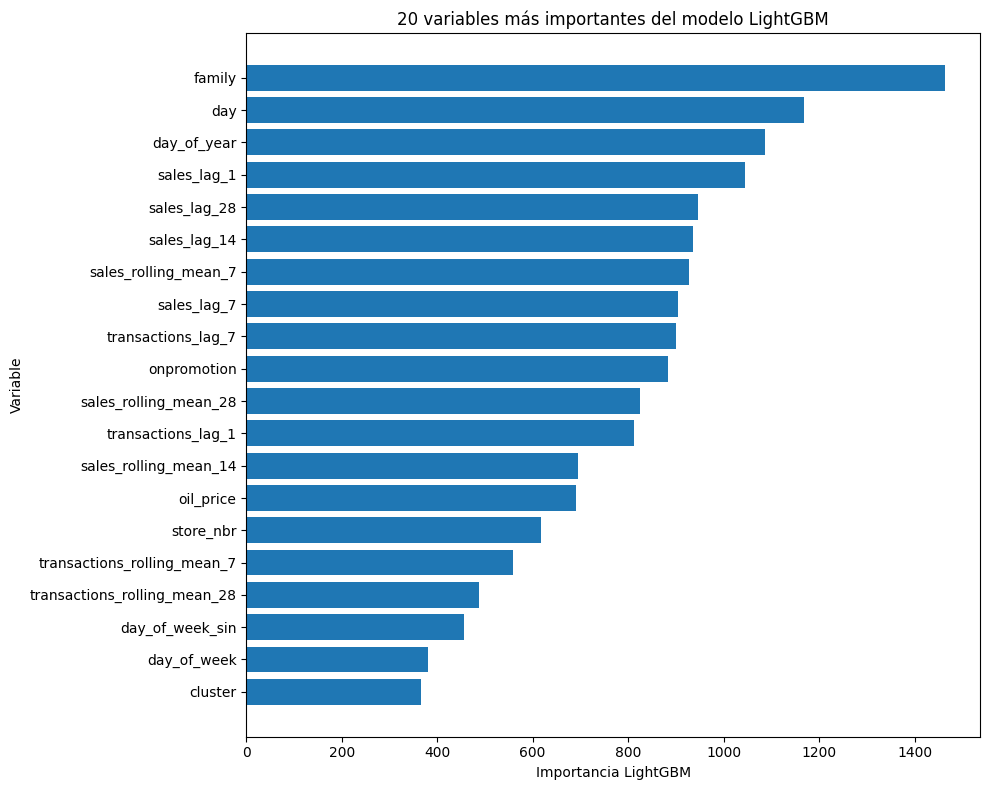

In [21]:
# =============================================================================
# GRÁFICO DE IMPORTANCIA GLOBAL
# =============================================================================

top_features = (
    global_importance
    .head(20)
    .sort_values("importance")
)


plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.xlabel(
    "Importancia LightGBM"
)

plt.ylabel(
    "Variable"
)

plt.title(
    "20 variables más importantes del modelo LightGBM"
)

plt.tight_layout()

plt.savefig(
    INTERPRETABILITY_FIGURES_PATH / "feature_importance_lightgbm.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [22]:
# =============================================================================
# 8.4. IMPORTANCIA POR GRUPOS DE VARIABLES
# =============================================================================

def feature_group(feature):

    if (
        feature.startswith("sales_lag")
        or feature.startswith("sales_rolling")
    ):
        return "Historial de ventas"

    elif feature == "onpromotion":
        return "Promociones"

    elif (
        "holiday" in feature
        or feature == "is_extra_work_day"
    ):
        return "Festivos"

    elif feature in {
        "day_of_week",
        "day_of_week_sin",
        "day_of_week_cos",
        "week_of_year",
        "is_weekend",
    }:
        return "Patrón semanal"

    elif feature in {
        "year",
        "month",
        "day",
        "day_of_year",
        "quarter",
        "time_index",
        "month_sin",
        "month_cos",
        "day_of_year_sin",
        "day_of_year_cos",
        "is_month_start",
        "is_month_end",
        "is_quarter_start",
        "is_quarter_end",
    }:
        return "Calendario"

    elif feature.startswith("transactions"):
        return "Transacciones"

    elif feature == "oil_price":
        return "Petróleo"

    elif feature in {
        "store_nbr",
        "family",
        "city",
        "state",
        "type",
        "cluster",
    }:
        return "Tienda y producto"

    else:
        return "Otros"


global_importance[
    "feature_group"
] = (
    global_importance["feature"]
    .apply(feature_group)
)


importance_by_group = (
    global_importance
    .groupby(
        "feature_group"
    )["importance"]
    .sum()
    .sort_values(
        ascending=False
    )
    .reset_index()
)


display(
    importance_by_group
)

,feature_group,importance
0,Historial de ventas,6278
1,Tienda y producto,3130
2,Calendario,3038
3,Transacciones,2759
4,Patrón semanal,1453
5,Promociones,883
6,Petróleo,691
7,Festivos,368


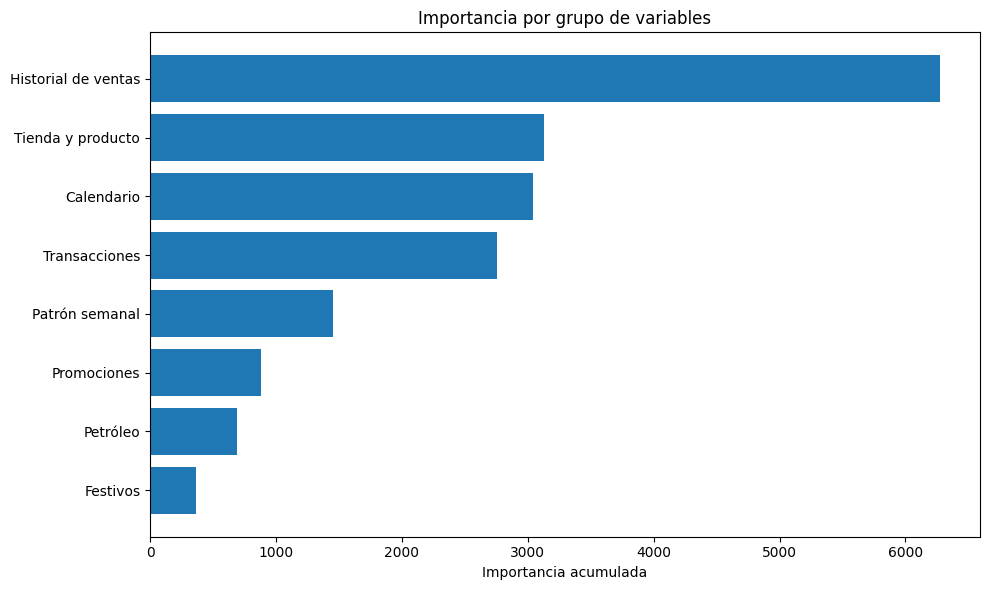

In [23]:
plt.figure(
    figsize=(10, 6)
)

plot_data = (
    importance_by_group
    .sort_values("importance")
)

plt.barh(
    plot_data["feature_group"],
    plot_data["importance"],
)

plt.xlabel(
    "Importancia acumulada"
)

plt.title(
    "Importancia por grupo de variables"
)

plt.tight_layout()

plt.savefig(
    INTERPRETABILITY_FIGURES_PATH / "importancia_grupos_variables.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [24]:
# =============================================================================
# 8.5. CARGA DE LAS VARIABLES DEL TEST
# =============================================================================

SPLIT_PATH = (
    PROCESSED_DATA_PATH
    / "temporal_split_dates.csv"
)

split_dates = pd.read_csv(
    SPLIT_PATH,
    parse_dates=[
        "start_date",
        "end_date",
    ],
)

test_row = split_dates.loc[
    split_dates["partition"]
    == "test"
].iloc[0]

test_start = test_row["start_date"]
test_end = test_row["end_date"]

required_columns = [
    "date",
    "sales",
    *feature_columns,
]

required_columns = list(
    dict.fromkeys(
        required_columns
    )
)

test_data = pd.read_parquet(
    PROCESSED_DATA_PATH
    / "train_prepared.parquet",

    columns=required_columns,

    filters=[
        (
            "date",
            ">=",
            test_start,
        ),
        (
            "date",
            "<=",
            test_end,
        ),
    ],
)

X_test = (
    test_data[
        feature_columns
    ]
    .reset_index(drop=True)
)

y_test = (
    test_data["sales"]
    .reset_index(drop=True)
)

print(
    "X_test:",
    X_test.shape
)

X_test: (49896, 43)


In [25]:
# Transformación exactamente igual a la utilizada
# durante el entrenamiento final.

X_test_encoded = (
    preprocessor.transform(
        X_test
    )
)

X_test_encoded = np.asarray(
    X_test_encoded,
    dtype=np.float32,
)

print(
    X_test_encoded.shape
)

(49896, 43)


In [ ]:
# =============================================================================
# 8.6. PERMUTATION IMPORTANCE
# =============================================================================

from sklearn.inspection import permutation_importance

SAMPLE_SIZE = min(
    10000,
    len(X_test_encoded),
)

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_test_encoded),
    size=SAMPLE_SIZE,
    replace=False,
)


X_perm = (
    X_test_encoded[
        sample_indices
    ]
)

y_perm = (
    np.log1p(
        y_test.iloc[
            sample_indices
        ].to_numpy(
            dtype=np.float32
        )
    )
)


permutation_result = (
    permutation_importance(
        best_model,
        X_perm,
        y_perm,
        scoring="neg_root_mean_squared_error",
        n_repeats=5,
        random_state=42,
        n_jobs=1,
    )
)


permutation_df = pd.DataFrame(
    {
        "feature": real_feature_order,

        "importance_mean":
            permutation_result
            .importances_mean,

        "importance_std":
            permutation_result
            .importances_std,
    }
)


permutation_df = (
    permutation_df
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    permutation_df.head(20)
)

,feature,importance_mean,importance_std
0,sales_rolling_mean_7,0.786577,0.007969
1,sales_lag_1,0.551218,0.006045
2,sales_rolling_mean_14,0.327682,0.003694
3,onpromotion,0.181685,0.004415
4,sales_rolling_mean_28,0.100316,0.001344
5,sales_lag_7,0.094646,0.000603
6,sales_lag_14,0.039990,0.000560
7,sales_lag_28,0.027094,0.001102
8,family,0.014585,0.000308
9,transactions_lag_7,0.005408,0.000606


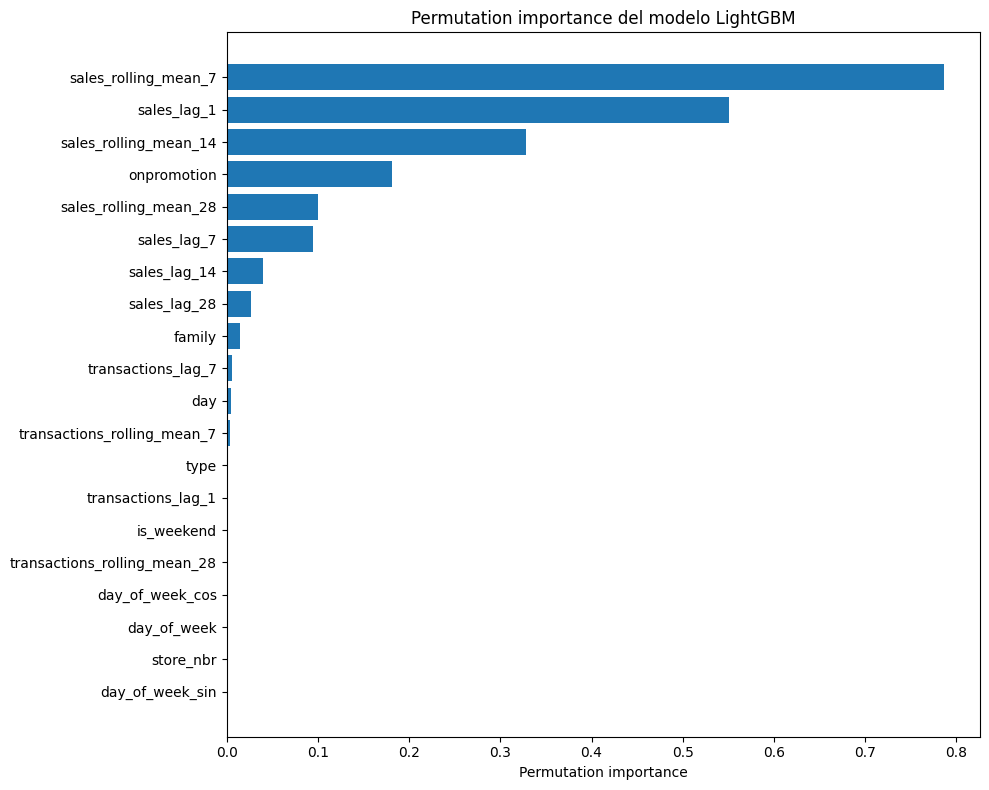

In [27]:
top_permutation = (
    permutation_df
    .head(20)
    .sort_values(
        "importance_mean"
    )
)


plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_permutation["feature"],
    top_permutation["importance_mean"],
)

plt.xlabel(
    "Permutation importance"
)

plt.title(
    "Permutation importance del modelo LightGBM"
)

plt.tight_layout()

plt.savefig(
    INTERPRETABILITY_FIGURES_PATH / "permutation_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [28]:
%pip install shap


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
# =============================================================================
# 8.7. SHAP
# =============================================================================

import shap


# Para evitar problemas de RAM utilizamos una muestra.
SHAP_SAMPLE_SIZE = min(
    5000,
    len(X_test_encoded),
)


rng = np.random.RandomState(42)

shap_indices = rng.choice(
    len(X_test_encoded),
    size=SHAP_SAMPLE_SIZE,
    replace=False,
)


X_shap = (
    X_test_encoded[
        shap_indices
    ]
)


# LightGBM puede utilizar TreeExplainer,
# que es mucho más eficiente que SHAP genérico.

explainer = shap.TreeExplainer(
    best_model
)


shap_values = (
    explainer.shap_values(
        X_shap
    )
)

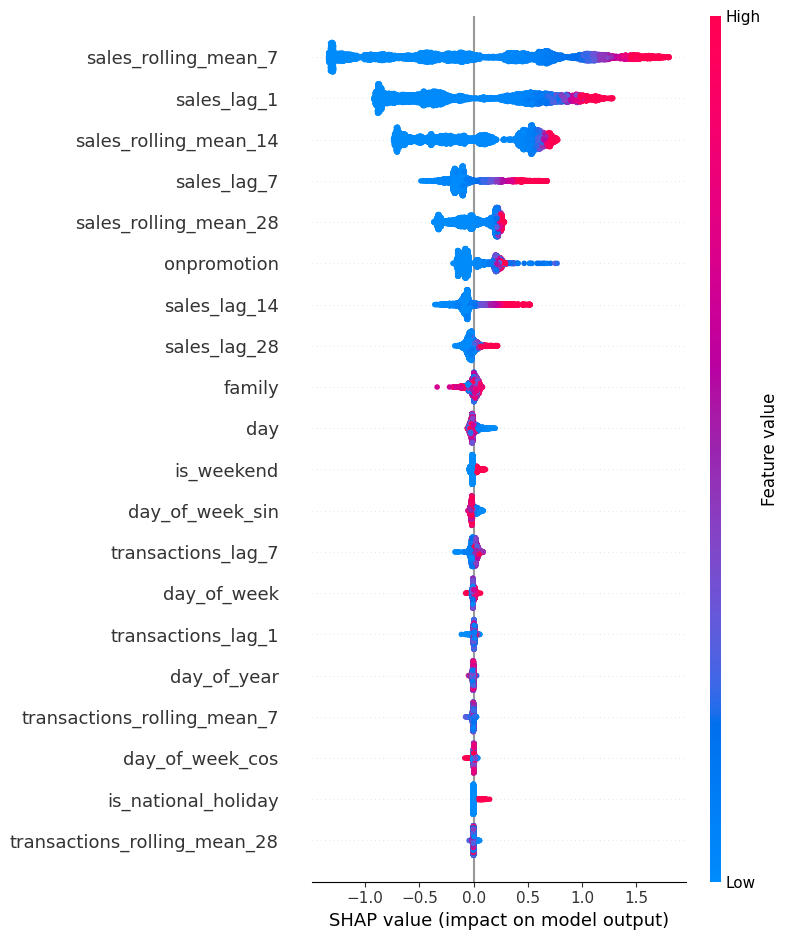

In [30]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=real_feature_order,
    max_display=20,
    show=False,
)

plt.savefig(
    INTERPRETABILITY_FIGURES_PATH / "shap_summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


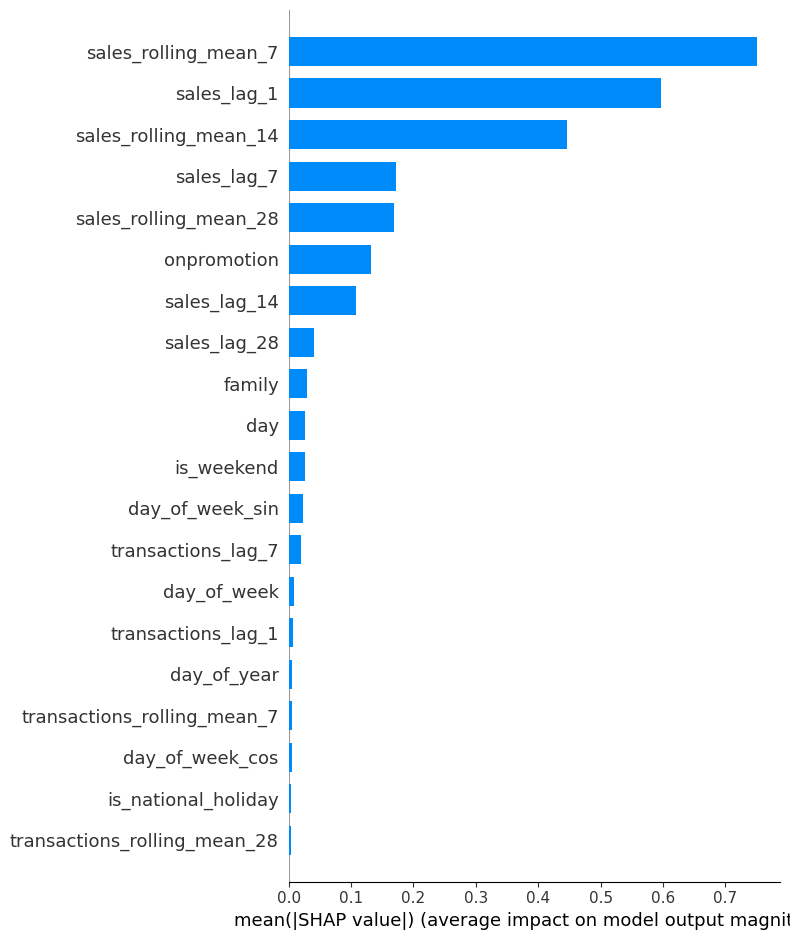

In [31]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=real_feature_order,
    plot_type="bar",
    max_display=20,
    show=False,
)

plt.savefig(
    INTERPRETABILITY_FIGURES_PATH / "shap_importance_bar.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 8.10. Promociones según la familia

In [32]:
# =============================================================================
# 8.10. EFECTO DE LAS PROMOCIONES SEGÚN LA FAMILIA
# =============================================================================

# Partimos de las predicciones del modelo ganador.
evaluation_analysis = evaluation_df.copy()


# -----------------------------------------------------------------------------
# Comprobamos si onpromotion ya está disponible
# -----------------------------------------------------------------------------

if "onpromotion" not in evaluation_analysis.columns:

    promotion_data = (
        test_data[
            [
                "date",
                "store_nbr",
                "family",
                "onpromotion",
            ]
        ]
        .copy()
    )

    # Evitamos duplicados antes del merge.
    promotion_data = (
        promotion_data
        .drop_duplicates(
            subset=[
                "date",
                "store_nbr",
                "family",
            ]
        )
    )

    evaluation_analysis = (
        evaluation_analysis
        .merge(
            promotion_data,
            on=[
                "date",
                "store_nbr",
                "family",
            ],
            how="left",
            validate="one_to_one",
        )
    )


# -----------------------------------------------------------------------------
# Si existen columnas _x/_y debido a una ejecución anterior, las unificamos
# -----------------------------------------------------------------------------

if "onpromotion_x" in evaluation_analysis.columns:

    if "onpromotion_y" in evaluation_analysis.columns:

        evaluation_analysis["onpromotion"] = (
            evaluation_analysis["onpromotion_x"]
            .combine_first(
                evaluation_analysis["onpromotion_y"]
            )
        )

        evaluation_analysis = (
            evaluation_analysis
            .drop(
                columns=[
                    "onpromotion_x",
                    "onpromotion_y",
                ]
            )
        )

    else:

        evaluation_analysis = (
            evaluation_analysis
            .rename(
                columns={
                    "onpromotion_x":
                    "onpromotion"
                }
            )
        )


elif "onpromotion_y" in evaluation_analysis.columns:

    evaluation_analysis = (
        evaluation_analysis
        .rename(
            columns={
                "onpromotion_y":
                "onpromotion"
            }
        )
    )


# -----------------------------------------------------------------------------
# Comprobación
# -----------------------------------------------------------------------------

assert "onpromotion" in evaluation_analysis.columns, (
    "No se ha podido recuperar la variable onpromotion."
)


print(
    "Valores nulos en onpromotion:",
    evaluation_analysis["onpromotion"].isna().sum()
)


# -----------------------------------------------------------------------------
# Con promoción / sin promoción
# -----------------------------------------------------------------------------

evaluation_analysis[
    "promotion_group"
] = np.where(
    evaluation_analysis["onpromotion"] > 0,
    "Con promoción",
    "Sin promoción",
)


# -----------------------------------------------------------------------------
# Error absoluto
# -----------------------------------------------------------------------------

evaluation_analysis[
    "absolute_error"
] = np.abs(
    evaluation_analysis["sales"]
    - evaluation_analysis["prediction"]
)


# -----------------------------------------------------------------------------
# Análisis por familia y promoción
# -----------------------------------------------------------------------------

promotion_by_family = (
    evaluation_analysis
    .groupby(
        [
            "family",
            "promotion_group",
        ],
        observed=True,
    )
    .agg(
        mean_sales=(
            "sales",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        MAE=(
            "absolute_error",
            "mean",
        ),
        observations=(
            "sales",
            "size",
        ),
    )
    .reset_index()
)


display(
    promotion_by_family
)

Valores nulos en onpromotion: 0


,family,promotion_group,mean_sales,mean_prediction,MAE,observations
0,AUTOMOTIVE,Con promoción,8.812500,7.163021,2.779509,16
1,AUTOMOTIVE,Sin promoción,7.302807,6.351402,2.831969,1496
2,BABY CARE,Con promoción,3.000000,1.585591,1.414409,1
3,BABY CARE,Sin promoción,0.176704,0.126403,0.220443,1511
4,BEAUTY,Con promoción,9.037846,7.759151,2.778745,687
...,...,...,...,...,...,...
59,PRODUCE,Sin promoción,2465.756348,2380.330078,267.484924,8
60,SCHOOL AND OFFICE SUPPLIES,Con promoción,190.591064,121.459785,86.603195,291
61,SCHOOL AND OFFICE SUPPLIES,Sin promoción,1.746110,0.760352,1.421715,1221
62,SEAFOOD,Con promoción,20.154867,19.176527,4.516128,329


In [33]:
# =============================================================================
# INCREMENTO DE LA PREDICCIÓN POR PROMOCIÓN, SEGÚN FAMILIA
# =============================================================================

promotion_pivot = promotion_by_family.pivot(
    index="family",
    columns="promotion_group",
    values="mean_prediction",
)

promotion_pivot["incremento_prediccion"] = (
    promotion_pivot["Con promoción"]
    - promotion_pivot["Sin promoción"]
)

promotion_pivot = promotion_pivot.sort_values(
    "incremento_prediccion",
    ascending=False,
)

print("5 familias donde el modelo predice mayor incremento por promoción:")
display(promotion_pivot.head())

print("5 familias donde el modelo predice menor incremento (o caída) por promoción:")
display(promotion_pivot.tail())


5 familias donde el modelo predice mayor incremento por promoción:


promotion_group,Con promoción,Sin promoción,incremento_prediccion
family,,,
GROCERY I,4558.323242,4064.897705,493.425537
MEATS,548.916626,336.311310,212.605316
BEVERAGES,3539.529785,3361.033203,178.496582
SCHOOL AND OFFICE SUPPLIES,121.459785,0.760352,120.699432
DAIRY,857.885986,762.424011,95.461975


5 familias donde el modelo predice menor incremento (o caída) por promoción:


promotion_group,Con promoción,Sin promoción,incremento_prediccion
family,,,
PREPARED FOODS,66.308289,89.725174,-23.416885
EGGS,171.199478,214.200760,-43.001282
BREAD/BAKERY,488.116211,671.059875,-182.943665
BOOKS,NaN,0.022166,NaN
HOME APPLIANCES,NaN,0.245602,NaN


In [34]:
print(
    evaluation_analysis[
        [
            "family",
            "onpromotion",
            "promotion_group",
            "sales",
            "prediction",
            "absolute_error",
        ]
    ].head()
)

       family  onpromotion promotion_group   sales   prediction  \
0  AUTOMOTIVE            0   Sin promoción     7.0     3.518848   
1   BABY CARE            0   Sin promoción     0.0     0.070182   
2      BEAUTY            0   Sin promoción     3.0     3.471102   
3   BEVERAGES           34   Con promoción  2369.0  2440.361084   
4       BOOKS            0   Sin promoción     0.0     0.271482   

   absolute_error  
0        3.481152  
1        0.070182  
2        0.471102  
3       71.361084  
4        0.271482  


In [35]:
# =============================================================================
# 8.11. ERRORES POR TIENDA
# =============================================================================

error_by_store = (
    evaluation_analysis
    .groupby(
        "store_nbr",
        observed=True,
    )
    .agg(
        MAE=(
            "absolute_error",
            "mean",
        ),

        mean_sales=(
            "sales",
            "mean",
        ),

        observations=(
            "sales",
            "size",
        ),
    )
    .sort_values(
        "MAE",
        ascending=False,
    )
    .reset_index()
)


display(
    error_by_store.head(10)
)

,store_nbr,MAE,mean_sales,observations
0,44,153.487305,1304.051270,924
1,47,129.434036,1128.631104,924
2,45,119.180466,1222.129272,924
3,40,109.402496,521.320923,924
4,46,105.739326,899.056274,924
5,39,105.364662,501.413757,924
6,48,97.121872,774.938293,924
7,3,90.073715,1056.010864,924
8,52,85.168930,707.879395,924
9,49,85.127457,985.578979,924


In [36]:
# =============================================================================
# 8.12. ERRORES POR FAMILIA
# =============================================================================

error_by_family = (
    evaluation_analysis
    .groupby(
        "family",
        observed=True,
    )
    .agg(
        MAE=(
            "absolute_error",
            "mean",
        ),

        mean_sales=(
            "sales",
            "mean",
        ),

        observations=(
            "sales",
            "size",
        ),
    )
    .sort_values(
        "MAE",
        ascending=False,
    )
    .reset_index()
)


display(
    error_by_family.head(10)
)

,family,MAE,mean_sales,observations
0,BEVERAGES,504.418274,3539.587891,1512
1,GROCERY I,498.327972,4567.357910,1512
2,CLEANING,275.970093,1281.584717,1512
3,PRODUCE,214.582855,2296.604248,1512
4,DAIRY,82.663689,840.982117,1512
5,BREAD/BAKERY,60.473751,533.939453,1512
6,MEATS,50.549770,376.899689,1512
7,HOME CARE,50.117073,305.679230,1512
8,PERSONAL CARE,49.766655,316.404755,1512
9,POULTRY,48.162704,381.344116,1512


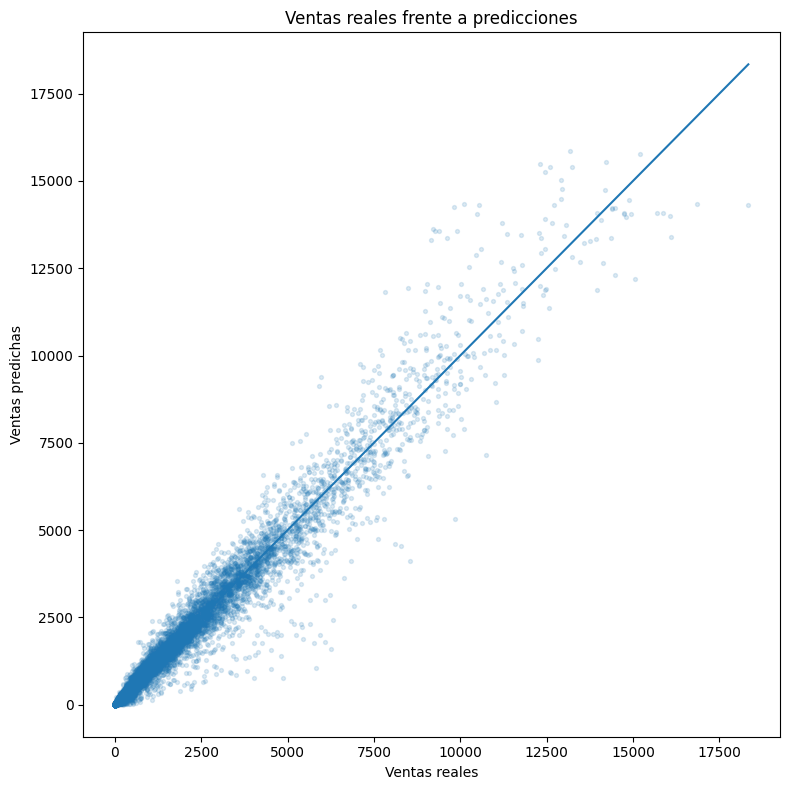

In [37]:
# =============================================================================
# 8.13. VALORES REALES VS PREDICCIONES
# =============================================================================

plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    evaluation_analysis["sales"],
    evaluation_analysis["prediction"],
    alpha=0.15,
    s=8,
)

maximum_value = max(
    evaluation_analysis["sales"].max(),
    evaluation_analysis["prediction"].max(),
)

plt.plot(
    [0, maximum_value],
    [0, maximum_value],
)

plt.xlabel(
    "Ventas reales"
)

plt.ylabel(
    "Ventas predichas"
)

plt.title(
    "Ventas reales frente a predicciones"
)

plt.tight_layout()

plt.savefig(
    INTERPRETABILITY_FIGURES_PATH / "real_vs_predicho_test.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

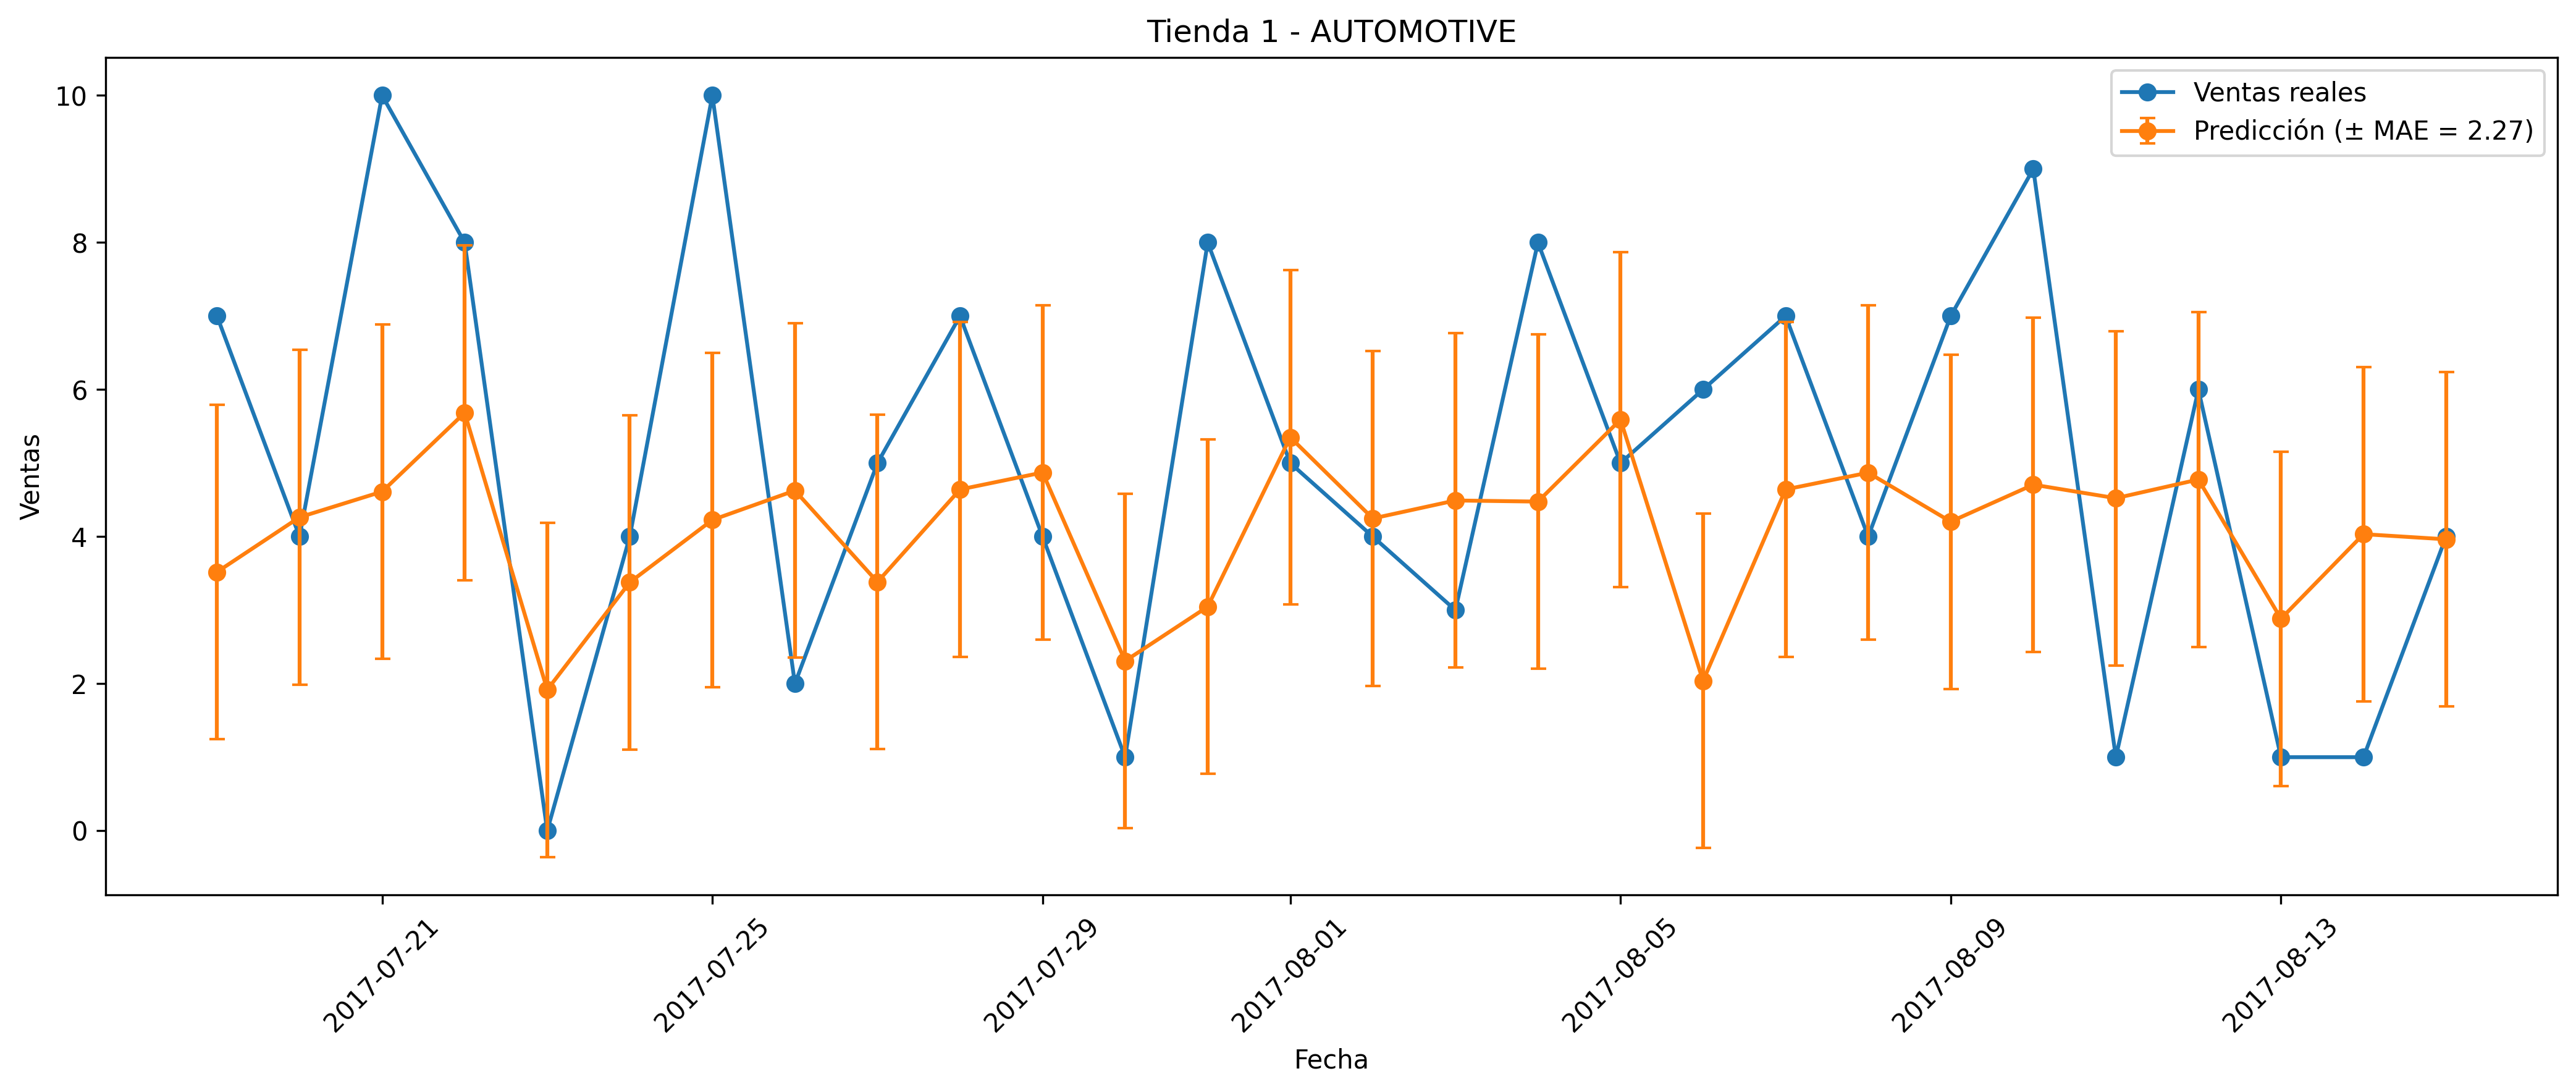

In [ ]:
# =============================================================================
# 8.14. EJEMPLO DE SERIE TEMPORAL
# =============================================================================

EXAMPLE_STORE = 1

EXAMPLE_FAMILY = (
    evaluation_analysis[
        "family"
    ].iloc[0]
)


example_series = (
    evaluation_analysis.loc[
        (
            evaluation_analysis[
                "store_nbr"
            ] == EXAMPLE_STORE
        )
        &
        (
            evaluation_analysis[
                "family"
            ] == EXAMPLE_FAMILY
        )
    ]
    .sort_values("date")
)

example_mae = (
    (example_series["sales"] - example_series["prediction"])
    .abs()
    .mean()
)

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    example_series["date"],
    example_series["sales"],
    marker="o",
    label="Ventas reales",
)

plt.errorbar(
    example_series["date"],
    example_series["prediction"],
    yerr=example_mae,
    marker="o",
    capsize=3,
    label=f"Predicción (± MAE = {example_mae:.2f})",
)

plt.xlabel("Fecha")
plt.ylabel("Ventas")

plt.title(
    f"Tienda {EXAMPLE_STORE} - "
    f"{EXAMPLE_FAMILY}"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    INTERPRETABILITY_FIGURES_PATH / "serie_real_vs_predicha.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8.15.Análisis picos demanda

In [39]:
# =============================================================================
# 8.15. ANÁLISIS DE PICOS DE DEMANDA
# =============================================================================

peak_threshold = (
    evaluation_analysis[
        "sales"
    ]
    .quantile(0.90)
)


evaluation_analysis[
    "demand_level"
] = np.where(
    evaluation_analysis["sales"]
    >= peak_threshold,

    "Pico de demanda",

    "Demanda normal",
)


peak_analysis = (
    evaluation_analysis
    .groupby(
        "demand_level",
        observed=True,
    )
    .agg(
        mean_real=(
            "sales",
            "mean",
        ),

        mean_prediction=(
            "prediction",
            "mean",
        ),

        MAE=(
            "absolute_error",
            "mean",
        ),

        observations=(
            "sales",
            "size",
        ),
    )
    .reset_index()
)


peak_analysis[
    "prediction_bias"
] = (
    peak_analysis[
        "mean_prediction"
    ]
    -
    peak_analysis[
        "mean_real"
    ]
)


display(
    peak_analysis
)

,demand_level,mean_real,mean_prediction,MAE,observations,prediction_bias
0,Demanda normal,135.017670,136.485367,21.667610,44906,1.467697
1,Pico de demanda,3481.716309,3460.963623,428.956726,4990,-20.752686


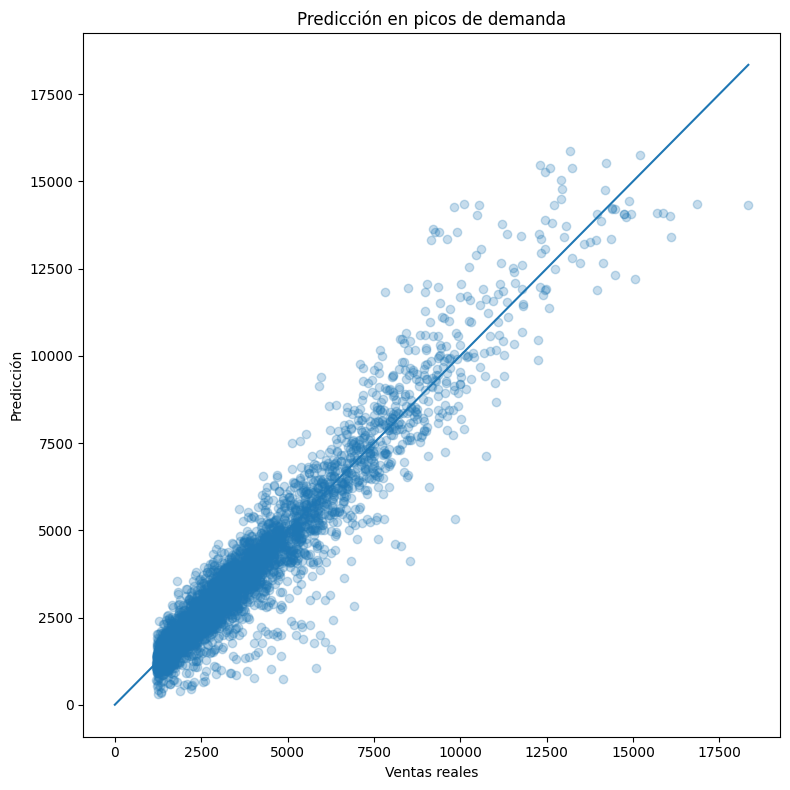

In [40]:
# Gráfico de picos

peak_rows = (
    evaluation_analysis[
        evaluation_analysis[
            "demand_level"
        ]
        == "Pico de demanda"
    ]
)


plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    peak_rows["sales"],
    peak_rows["prediction"],
    alpha=0.25,
)

maximum_peak = max(
    peak_rows["sales"].max(),
    peak_rows["prediction"].max(),
)

plt.plot(
    [0, maximum_peak],
    [0, maximum_peak],
)

plt.xlabel(
    "Ventas reales"
)

plt.ylabel(
    "Predicción"
)

plt.title(
    "Predicción en picos de demanda"
)

plt.tight_layout()

plt.savefig(
    INTERPRETABILITY_FIGURES_PATH / "picos_demanda.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8.16. Generalización temporal

In [41]:
# =============================================================================
# 8.17. RESUMEN DE INTERPRETABILIDAD
# =============================================================================

print("=" * 80)
print("RESUMEN DE INTERPRETABILIDAD")
print("=" * 80)


print(
    "\nVariable más importante:"
)

print(
    global_importance.iloc[0][
        ["feature", "importance"]
    ]
)


print(
    "\nGrupo de variables más importante:"
)

print(
    importance_by_group.iloc[0]
)


print(
    "\nTienda con mayor MAE:"
)

print(
    error_by_store.iloc[0][
        [
            "store_nbr",
            "MAE",
        ]
    ]
)


print(
    "\nFamilia con mayor MAE:"
)

print(
    error_by_family.iloc[0][
        [
            "family",
            "MAE",
        ]
    ]
)


peak_row = (
    peak_analysis.loc[
        peak_analysis[
            "demand_level"
        ]
        == "Pico de demanda"
    ]
    .iloc[0]
)


print(
    "\nSesgo en picos de demanda:"
)

print(
    f"{peak_row['prediction_bias']:.2f}"
)


if (
    peak_row[
        "prediction_bias"
    ] < 0
):

    print(
        "El modelo tiende a "
        "SUBESTIMAR los picos."
    )

elif (
    peak_row[
        "prediction_bias"
    ] > 0
):

    print(
        "El modelo tiende a "
        "SOBREESTIMAR los picos."
    )

else:

    print(
        "No se observa sesgo medio "
        "en los picos."
    )

RESUMEN DE INTERPRETABILIDAD

Variable más importante:
feature       family
importance      1464
Name: 0, dtype: object

Grupo de variables más importante:
feature_group    Historial de ventas
importance                      6278
Name: 0, dtype: object

Tienda con mayor MAE:
store_nbr     44.000000
MAE          153.487305
Name: 0, dtype: float64

Familia con mayor MAE:
family     BEVERAGES
MAE       504.418274
Name: 0, dtype: object

Sesgo en picos de demanda:
-20.75
El modelo tiende a SUBESTIMAR los picos.
